# AudioAngleNet evaluation on ROS1 test pairs

Load test samples from `data/pairs_ros1`, run the trained audio-only DOA model, and inspect predictions on the LiDAR bird's-eye view together with the label bbox.

In [1]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass

from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib.patches import Polygon
from torch.utils.data import DataLoader

from dataloader.avped_audio_angle_dataloader import AVpedAudioAngleLoader
from network.audio_angle_net import AudioAngleNet

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

/home/kemove/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/kemove/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


## Configuration

Set `LOW_CUT_HZ` and `HIGH_CUT_HZ` to exactly the values used during training. Test loading never adds random background noise.

In [2]:
DATA_ROOT = 'data/pairs_ros1'
TEST_SPLIT = 'test'
OBJECT_FILTER = 'person'
AUDIO_CHANNELS = (1, 2, 3, 4)
FEATURE_TYPE = 'ipd'

# Select a checkpoint and its matching preprocessing configuration.
CHECKPOINT = Path('output_audio_angle_ros1_person_bandpass/model_best.pth')
LOW_CUT_HZ = 300.0
HIGH_CUT_HZ = 3000.0
FILTER_ORDER = 4

DROPOUT_RATE = 0.4
FEATURE_DIM = 128
HIDDEN_DIM = 64
KERNEL_NUM = 8
BATCH_SIZE = 32
NUM_WORKERS = 0
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Samples rendered in the visual inspection panel below.
VIS_SEQUENCE = 'person14'
VIS_STEMS = ['0001', '0002', '0003', '0004', '0005']

INPUT_CHANNELS = 1 + 2 * (len(AUDIO_CHANNELS) - 1) if FEATURE_TYPE == 'ipd' else len(AUDIO_CHANNELS)
print('device:', DEVICE)
print('checkpoint:', CHECKPOINT)
print('input channels:', INPUT_CHANNELS)

device: cuda:0
checkpoint: output_audio_angle_ros1_person_bandpass/model_best.pth
input channels: 7


In [3]:
test_data = AVpedAudioAngleLoader(
    root_path=DATA_ROOT,
    split=TEST_SPLIT,
    object_filter=OBJECT_FILTER,
    audio_channels=AUDIO_CHANNELS,
    feature_type=FEATURE_TYPE,
    return_angle=True,
    return_metadata=True,
)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

model = AudioAngleNet(
    dropout_rate=DROPOUT_RATE,
    feature_dim=FEATURE_DIM,
    hidden_dim=HIDDEN_DIM,
    kernel_num=KERNEL_NUM,
    audio_channels=INPUT_CHANNELS,
).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE, weights_only=True))
model.eval()

counts = Counter(sample['bag'] for sample in test_data.samples)
print('selected test sequences:', test_data.selected_sequences)
print('test samples:', len(test_data))
print('samples per sequence:', dict(counts))

selected test sequences: ['person14', 'person24']
test samples: 812
samples per sequence: {'person14': 341, 'person24': 471}


In [4]:
def wrap_rad(angle):
    return np.arctan2(np.sin(angle), np.cos(angle))

def circular_error_deg(pred_rad, target_rad):
    return np.degrees(np.abs(wrap_rad(pred_rad - target_rad)))

records = []
with torch.no_grad():
    for spec, _, gt_angle, meta in test_loader:
        pred_vector = model(spec.to(DEVICE)).cpu().numpy()
        pred_angle = np.arctan2(pred_vector[:, 0], pred_vector[:, 1])
        for index in range(len(pred_angle)):
            gt_rad = float(gt_angle[index])
            pred_rad = float(pred_angle[index])
            records.append({
                'sequence': meta['sequence'][index],
                'stem': meta['stem'][index],
                'gt_rad': gt_rad,
                'pred_rad': pred_rad,
                'gt_deg': float(np.degrees(gt_rad) % 360.0),
                'pred_deg': float(np.degrees(pred_rad) % 360.0),
                'error_deg': float(circular_error_deg(pred_rad, gt_rad)),
                'label': meta['label'][index],
                'lidar': meta['lidar'][index],
            })

results = pd.DataFrame(records).sort_values(['sequence', 'stem']).reset_index(drop=True)
summary = results.groupby('sequence').agg(frames=('stem', 'count'), mae_deg=('error_deg', 'mean'), median_deg=('error_deg', 'median'), max_deg=('error_deg', 'max'))
summary.loc['ALL'] = [len(results), results['error_deg'].mean(), results['error_deg'].median(), results['error_deg'].max()]
summary.round(3)

,frames,mae_deg,median_deg,max_deg
sequence,,,,
person14,341.0,38.482,19.726,163.773
person24,471.0,11.364,7.867,87.812
ALL,812.0,22.752,11.633,163.773


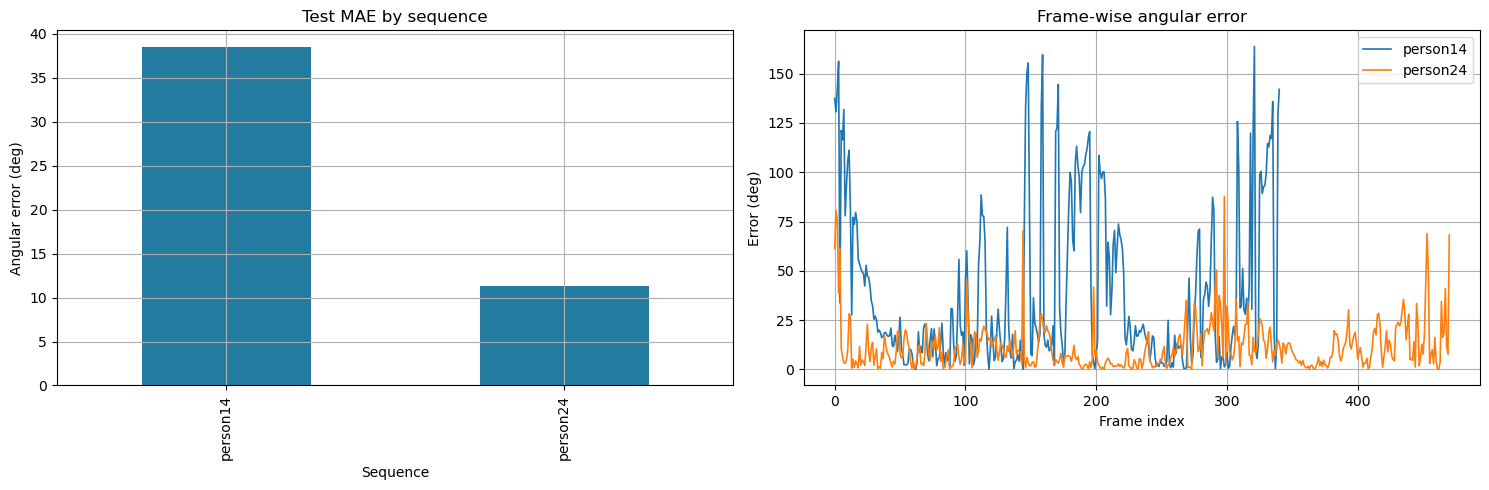

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sequence_summary = summary.drop(index='ALL')
sequence_summary['mae_deg'].plot.bar(ax=axes[0], color='#247ba0')
axes[0].set_title('Test MAE by sequence')
axes[0].set_ylabel('Angular error (deg)')
axes[0].set_xlabel('Sequence')

for sequence, group in results.groupby('sequence'):
    axes[1].plot(np.arange(len(group)), group['error_deg'].to_numpy(), label=sequence, linewidth=1.2)
axes[1].set_title('Frame-wise angular error')
axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('Error (deg)')
axes[1].legend()
fig.tight_layout()
plt.show()

## Visualize specified test samples

Red rectangle: the LiDAR bbox label used as DOA ground truth. Cyan ray: GT DOA. Orange ray: AudioAngleNet prediction.

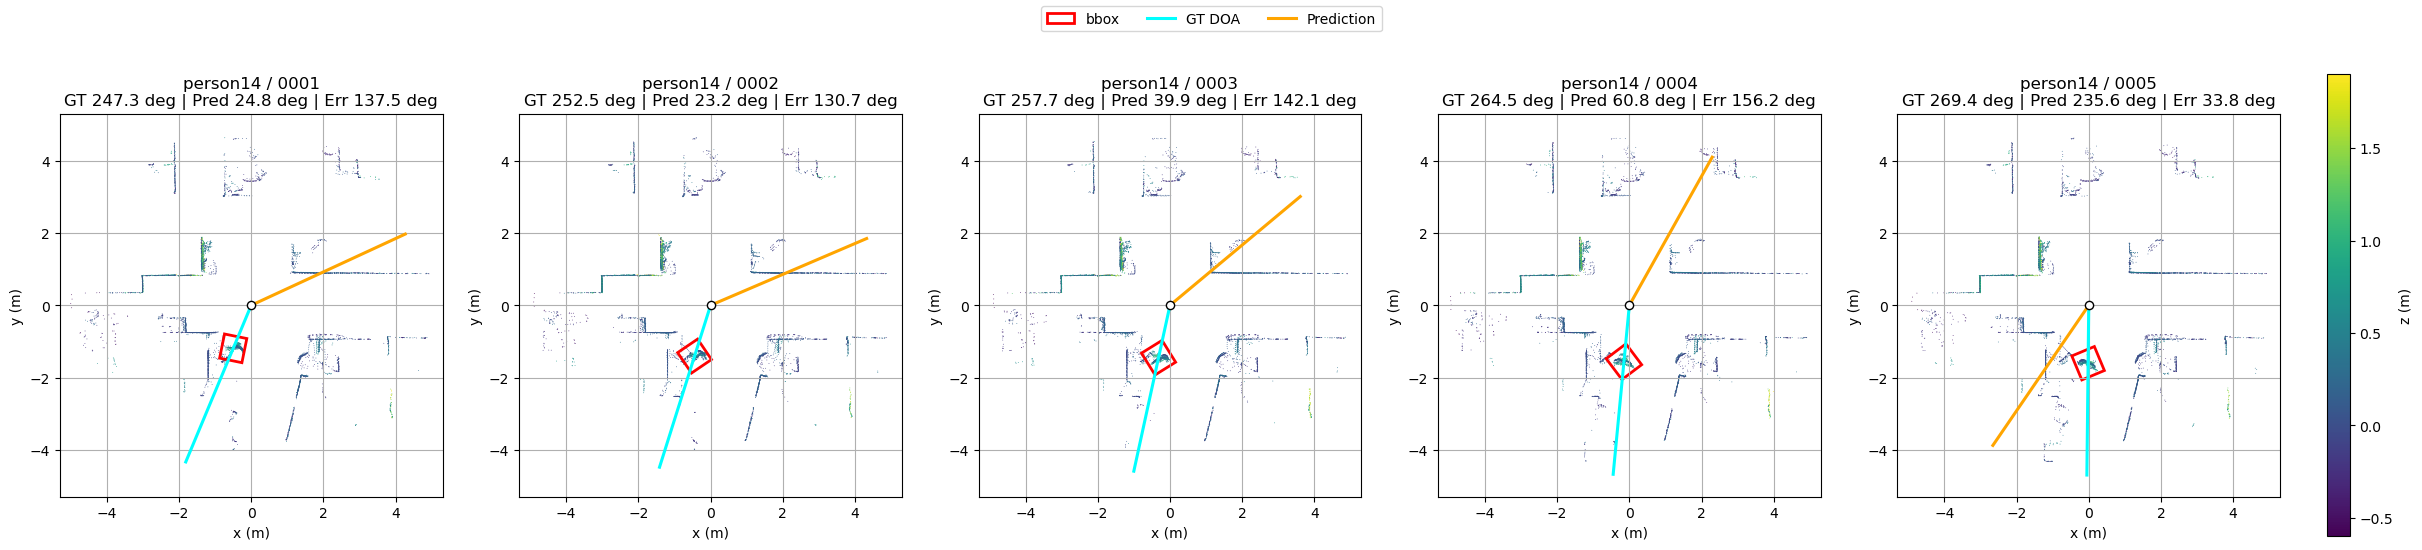

In [6]:
def load_labelcloud_box(path):
    lines = [line for line in Path(path).read_text().splitlines() if line.strip()]
    if len(lines) != 1:
        return None
    fields = lines[0].split()
    h, w, l = map(float, fields[8:11])
    x, y, z, yaw = map(float, fields[11:15])
    return np.asarray([x, y, z, l, w, h, yaw], dtype=np.float32)

def bbox_bev_corners(box):
    x, y, _, dx, dy, _, yaw = box
    corners = np.asarray([[dx / 2, dy / 2], [dx / 2, -dy / 2], [-dx / 2, -dy / 2], [-dx / 2, dy / 2]])
    rotation = np.asarray([[np.cos(yaw), -np.sin(yaw)], [np.sin(yaw), np.cos(yaw)]])
    return corners @ rotation.T + np.asarray([x, y])

def draw_doa_ray(ax, angle, color, label, length=4.7):
    ax.plot([0.0, length * np.cos(angle)], [0.0, length * np.sin(angle)], color=color, linewidth=2.2, label=label)

def visualize_prediction(row, ax, axis_limit=5.3):
    points = np.fromfile(row['lidar'], dtype=np.float32).reshape(-1, 4)
    box = load_labelcloud_box(row['label'])
    scatter = ax.scatter(points[:, 0], points[:, 1], c=points[:, 2], s=0.35, cmap='viridis', linewidths=0)
    if box is not None:
        ax.add_patch(Polygon(bbox_bev_corners(box), closed=True, fill=False, edgecolor='red', linewidth=2, label='bbox'))
    draw_doa_ray(ax, row['gt_rad'], 'cyan', 'GT DOA')
    draw_doa_ray(ax, row['pred_rad'], 'orange', 'Prediction')
    ax.scatter([0], [0], color='white', edgecolor='black', s=35, zorder=5)
    ax.set_xlim(-axis_limit, axis_limit)
    ax.set_ylim(-axis_limit, axis_limit)
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(f"{row['sequence']} / {row['stem']}\nGT {row['gt_deg']:.1f} deg | Pred {row['pred_deg']:.1f} deg | Err {row['error_deg']:.1f} deg")
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    return scatter

selected = results[(results['sequence'] == VIS_SEQUENCE) & (results['stem'].isin(VIS_STEMS))]
if selected.empty:
    raise ValueError(f'No samples selected for {VIS_SEQUENCE}: {VIS_STEMS}')
fig, axes = plt.subplots(1, len(selected), figsize=(6 * len(selected), 6), squeeze=False)
for ax, (_, row) in zip(axes.ravel(), selected.iterrows()):
    scatter = visualize_prediction(row, ax)
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
fig.colorbar(scatter, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label='z (m)')
plt.show()

## Inspect worst predictions

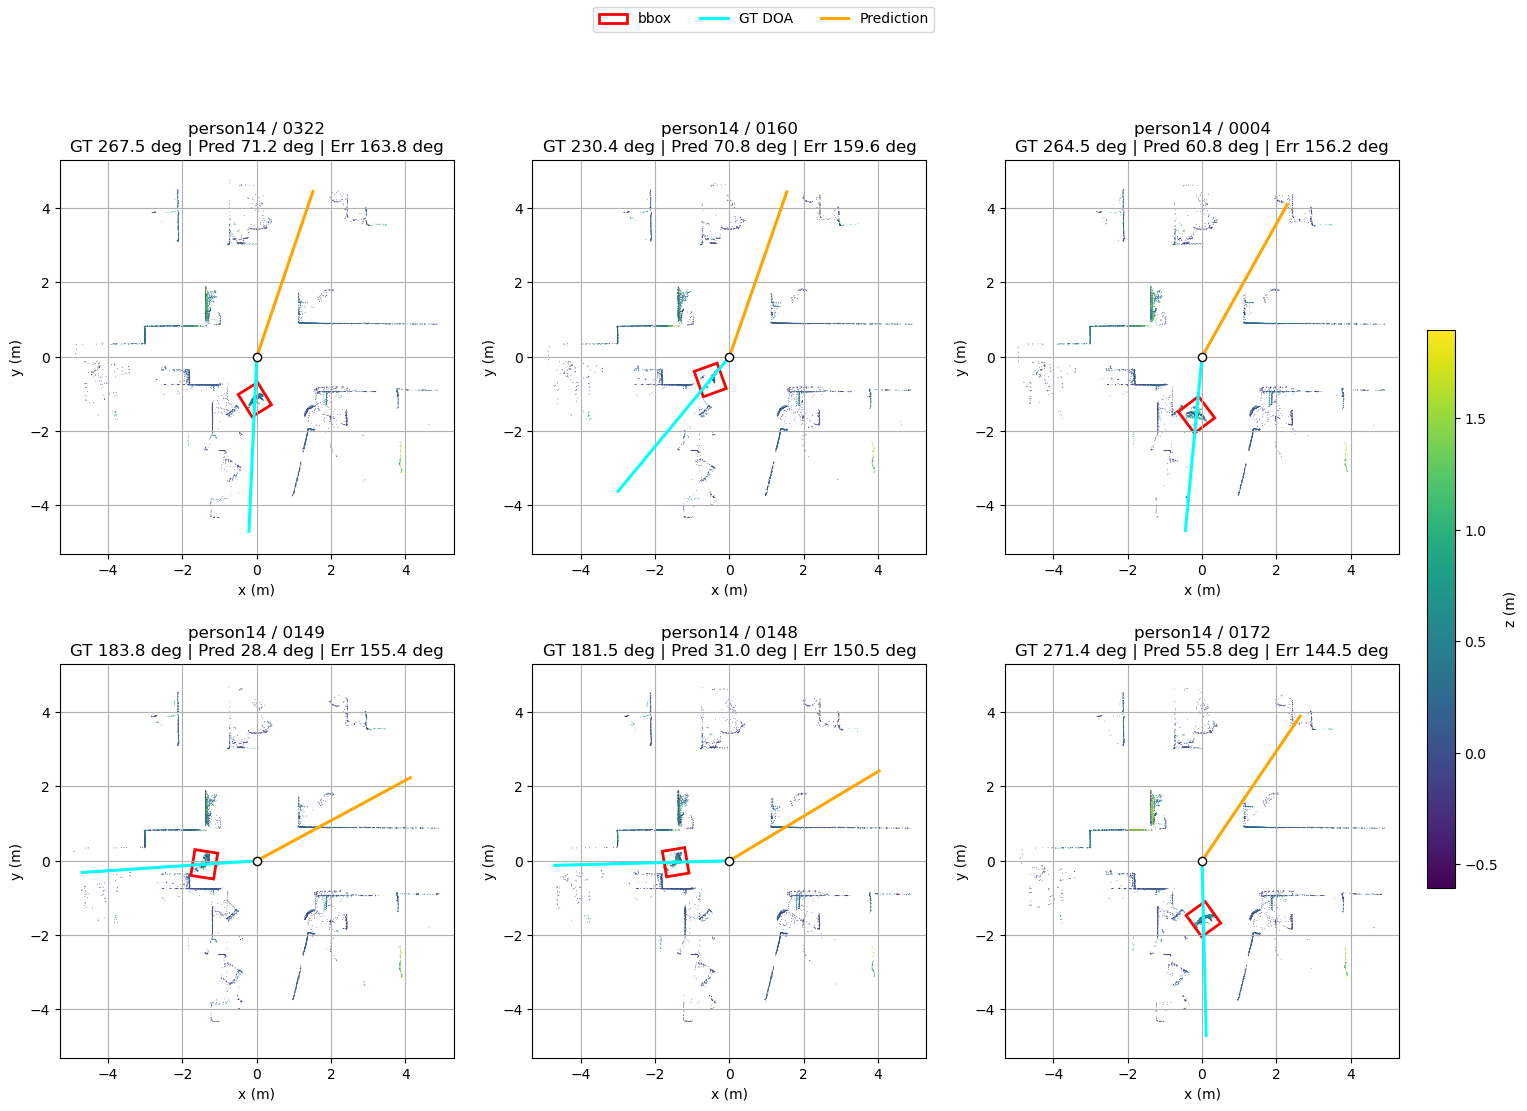

,sequence,stem,gt_deg,pred_deg,error_deg
321,person14,0322,267.451,71.224,163.773
159,person14,0160,230.395,70.803,159.592
3,person14,0004,264.531,60.780,156.250
148,person14,0149,183.842,28.413,155.429
147,person14,0148,181.505,30.974,150.532
171,person14,0172,271.357,55.849,144.492


In [7]:
TOP_K = 6
worst = results.sort_values('error_deg', ascending=False).head(TOP_K)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (_, row) in zip(axes.ravel(), worst.iterrows()):
    scatter = visualize_prediction(row, ax)
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)
fig.colorbar(scatter, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label='z (m)')
plt.show()
worst[['sequence', 'stem', 'gt_deg', 'pred_deg', 'error_deg']].round(3)

In [8]:
# Export visualizations for every evaluated sample.
EXPORT_DIR = Path('data/pairs_ros1/audio_angle_visualizations')
EXPORT_DPI = 130
EXPORT_AXIS_LIMIT = 5.3
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

export_records = []
for index, row in results.iterrows():
    sequence_dir = EXPORT_DIR / row['sequence']
    sequence_dir.mkdir(parents=True, exist_ok=True)
    output_path = sequence_dir / f"{row['stem']}.png"

    fig, ax = plt.subplots(figsize=(6, 6))
    scatter = visualize_prediction(row, ax, axis_limit=EXPORT_AXIS_LIMIT)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc='upper right', fontsize=8)
    fig.colorbar(scatter, ax=ax, fraction=0.045, pad=0.03, label='z (m)')
    fig.tight_layout()
    fig.savefig(output_path, dpi=EXPORT_DPI, bbox_inches='tight')
    plt.close(fig)

    export_records.append({
        'sequence': row['sequence'],
        'stem': row['stem'],
        'gt_deg': row['gt_deg'],
        'pred_deg': row['pred_deg'],
        'error_deg': row['error_deg'],
        'visualization': str(output_path),
    })

export_manifest = pd.DataFrame(export_records).sort_values('error_deg', ascending=False)
manifest_path = EXPORT_DIR / 'manifest.csv'
export_manifest.to_csv(manifest_path, index=False)
print(f'Exported {len(export_manifest)} visualizations to {EXPORT_DIR}')
print(f'Manifest: {manifest_path}')
export_manifest.head(10).round(3)

Exported 812 visualizations to data/pairs_ros1/audio_angle_visualizations
Manifest: data/pairs_ros1/audio_angle_visualizations/manifest.csv


,sequence,stem,gt_deg,pred_deg,error_deg,visualization
321,person14,0322,267.451,71.224,163.773,data/pairs_ros1/audio_angle_visualizations/per...
159,person14,0160,230.395,70.803,159.592,data/pairs_ros1/audio_angle_visualizations/per...
3,person14,0004,264.531,60.780,156.250,data/pairs_ros1/audio_angle_visualizations/per...
148,person14,0149,183.842,28.413,155.429,data/pairs_ros1/audio_angle_visualizations/per...
147,person14,0148,181.505,30.974,150.532,data/pairs_ros1/audio_angle_visualizations/per...
171,person14,0172,271.357,55.849,144.492,data/pairs_ros1/audio_angle_visualizations/per...
2,person14,0003,257.707,39.855,142.148,data/pairs_ros1/audio_angle_visualizations/per...
340,person14,0341,248.661,30.696,142.035,data/pairs_ros1/audio_angle_visualizations/per...
0,person14,0001,247.330,24.816,137.487,data/pairs_ros1/audio_angle_visualizations/per...
335,person14,0336,263.964,39.744,135.780,data/pairs_ros1/audio_angle_visualizations/per...
